In [1]:
import numpy as np
from numpy.typing import NDArray
from scipy.special import expit
import matplotlib.pyplot as plt

# Machine Learning
import autograd.numpy as anp
from autograd import grad
from autograd import elementwise_grad as egrad

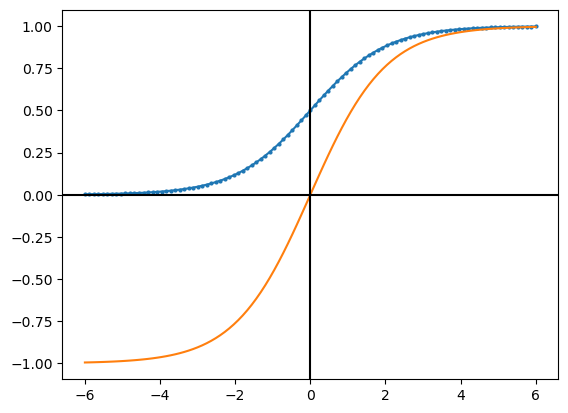

In [2]:
x = np.linspace(-6, 6 , 101)
plt.plot(x, expit(x), marker='o', markersize=2)
plt.plot(x, 2 * expit(x) - 1)
plt.axvline(x=0, c= 'k')
plt.axhline(y=0, c= 'k')
plt.show()

In [14]:
def sigmoid_fun(vX) -> NDArray :
    return 1.0 / (1.0 + anp.exp(-vX))

def objective_fun(mA, vX, vY) -> float:
    return 0.5 * (anp.linalg.norm(sigmoid_fun(mA @ vX) - vY, 2))**2

The objective function is given by:

$$ f \left( \boldsymbol{x} \right) = \frac{1}{2} {\left\| \sigma \left[ \boldsymbol{A} \boldsymbol{x} \right] - \boldsymbol{y} \right\|}_{2}^{2} $$

(101,)


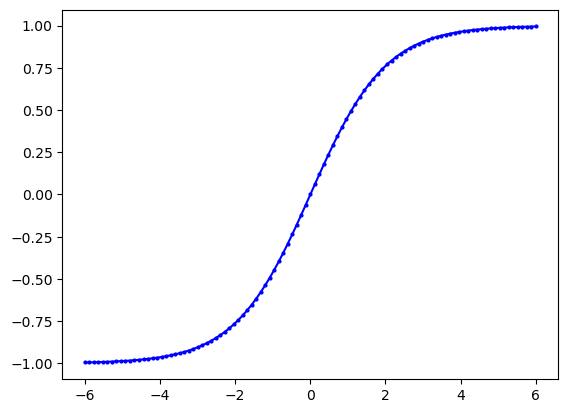

In [16]:
x = np.linspace(-6, 6, 101)
print(x.shape)
plt.plot(x, 2 * sigmoid_fun(x) -1, marker='o', c='b', markersize=2)
plt.show()

In [17]:
# here the goal is to build function which returns gradient in every point of sigmoid
def grad_sigmoid_fun(vX) -> NDArray:
    return  2 * sigmoid_fun(vX) * (1 - sigmoid_fun(vX))

(101,)


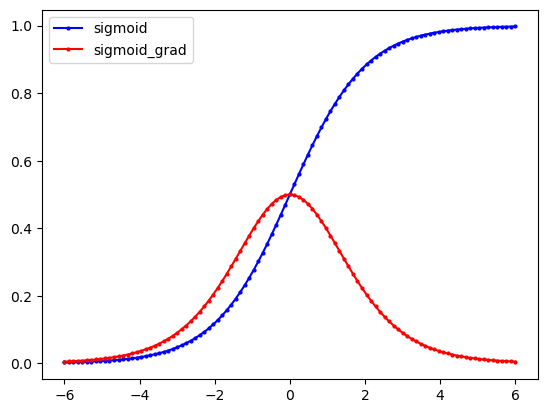

In [18]:
x = anp.linspace(-6, 6, 101)
print(x.shape)
plt.plot(x, sigmoid_fun(x), marker='o', c='b', markersize=2, label = 'sigmoid')
plt.plot(x, grad_sigmoid_fun(x),marker='o', c='red', markersize=2, label = 'sigmoid_grad')
plt.legend()
plt.show()

In [23]:
# here i want to build the same gradient but with auto grad without mannual calculation

vX = anp.linspace(-6, 6, 101)
func_handler = lambda vX: 2 * sigmoid_fun(vX) - 1
func_gradient = lambda vX : grad_sigmoid_fun(vX)
func_auto_grad = egrad(func_handler)

np.allclose(func_gradient(vX), func_auto_grad(vX))



True

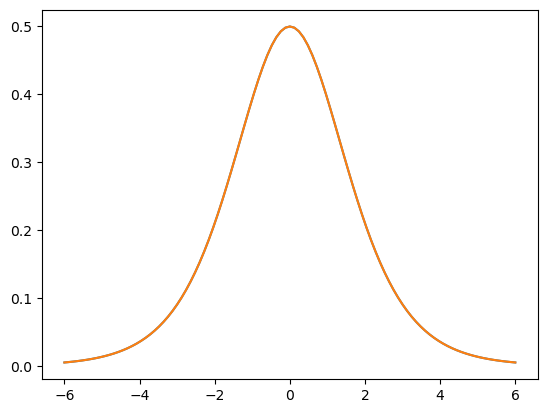

In [24]:
plt.plot(vX, func_gradient(vX))
plt.plot(vX, func_auto_grad(vX))
plt.show()

In [25]:
numRows = 10
numCols = 5
ε = 1e-6

In [42]:
vX = anp.random.rand(numCols)
mA = anp.random.rand(numRows, numCols)
vY = anp.random.rand(numRows)

In [ ]:
objective_fun(vX= vX, mA=mA, vY=vY)


np.float64(0.8280100135976096)